In [8]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    host="127.0.0.1",
    port=5432,
    database="user_behavior",
    user="postgres",
    password="Kikip@2100006"
)

df = pd.read_sql("SELECT COUNT(*) FROM events", conn)
print(df)


     count
0  2756101


/var/folders/jv/vr6jg3fx62z22hqdprdk65sc0000gn/T/ipykernel_21090/1732565458.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT COUNT(*) FROM events", conn)


In [9]:
# Query 1 - conversion rate by channel
df_cvr = pd.read_sql("""
    SELECT 
        discovery_channel,
        COUNT(*) AS total_users,
        SUM(purchased) AS converters,
        ROUND(100.0 * SUM(purchased)::numeric / COUNT(*), 2) AS cvr_pct
    FROM classified
    GROUP BY discovery_channel
    ORDER BY cvr_pct DESC
""", conn)

print(df_cvr)

/var/folders/jv/vr6jg3fx62z22hqdprdk65sc0000gn/T/ipykernel_21090/946602972.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cvr = pd.read_sql("""


  discovery_channel  total_users  converters  cvr_pct
0       browse_type         9446      1417.0    15.00
1             mixed       108083      3656.0     3.38
2       search_type      1290051      6646.0     0.52


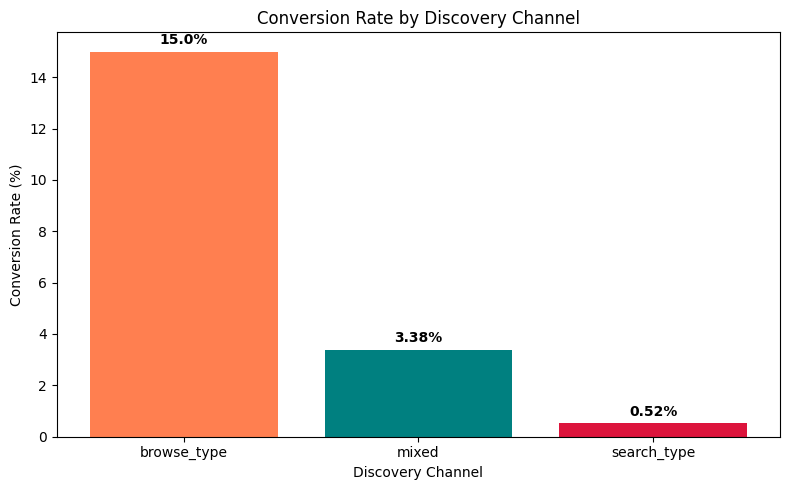

In [17]:
fig, ax = plt.subplots(figsize = (8, 5))

colors = ['coral', 'teal', 'crimson']

ax.bar(df_cvr['discovery_channel'], df_cvr['cvr_pct'], color=colors)

ax.set_title('Conversion Rate by Discovery Channel')
ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('Discovery Channel')

for i, v in enumerate(df_cvr['cvr_pct']):
    ax.text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('cvr_by_channel.png', dpi=150)
plt.show()


In [18]:
df_funnel = pd.read_sql("""
    SELECT 
        discovery_channel,
        ROUND(SUM(CASE WHEN event = 'addtocart' THEN 1 ELSE 0 END)::numeric / 
              SUM(CASE WHEN event = 'view' THEN 1 ELSE 0 END) * 100, 2) AS view_to_cart,
        ROUND(SUM(CASE WHEN event = 'transaction' THEN 1 ELSE 0 END)::numeric / 
              SUM(CASE WHEN event = 'addtocart' THEN 1 ELSE 0 END) * 100, 2) AS cart_to_purchase
    FROM events
    JOIN classified USING (visitorid)
    GROUP BY discovery_channel
""", conn)

print(df_funnel)

/var/folders/jv/vr6jg3fx62z22hqdprdk65sc0000gn/T/ipykernel_21090/30961584.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_funnel = pd.read_sql("""


  discovery_channel  view_to_cart  cart_to_purchase
0       browse_type          6.43             43.22
1             mixed          3.33             27.55
2       search_type          1.56             26.94


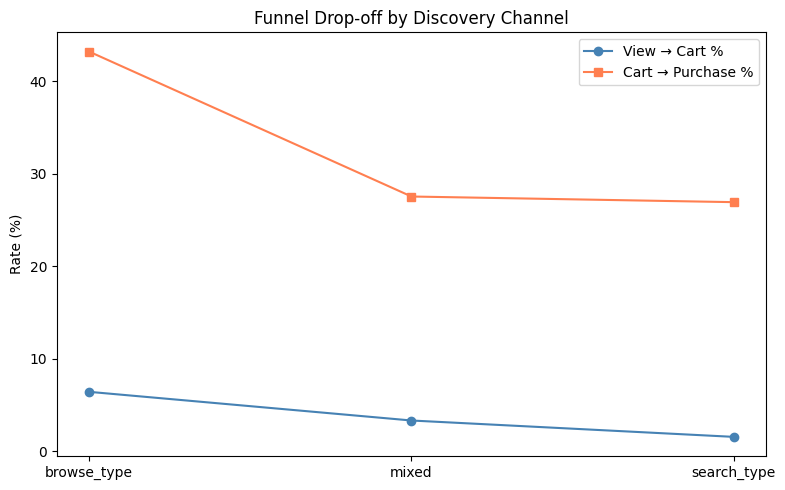

In [19]:
x = range(len(df_funnel))

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, df_funnel['view_to_cart'], marker='o', color='steelblue', label='View → Cart %')
ax.plot(x, df_funnel['cart_to_purchase'], marker='s', color='coral', label='Cart → Purchase %')

ax.set_xticks(x)
ax.set_xticklabels(df_funnel['discovery_channel'])
ax.set_title('Funnel Drop-off by Discovery Channel')
ax.set_ylabel('Rate (%)')
ax.legend()

plt.tight_layout()
plt.savefig('funnel_dropoff.png', dpi=150)
plt.show()